<a href="https://colab.research.google.com/github/joysujeeth1761/Adversarial_ML/blob/main/GRADIENT_BASED_ATTACKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FGSM(FAST GRADIENT SIGN METHOD)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
#LOADING MNIST DATASET
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.75MB/s]


In [ ]:
#Build CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2,2)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 5 * 5)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 3

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 162.8294
Epoch 2, Loss: 46.8181
Epoch 3, Loss: 31.9294


In [ ]:
def test_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Normal Accuracy: {accuracy:.2f}%")

In [ ]:
#Test Normal Accuracy
test_accuracy(model, test_loader)


Normal Accuracy: 99.02%


In [ ]:
#FGSM Attack Function
def fgsm_attack(model, loss_fn, image, label, epsilon):

    image.requires_grad = True

    output = model(image)

    loss = loss_fn(output, label)

    model.zero_grad()

    loss.backward()

    gradient = image.grad.data

    sign_gradient = gradient.sign()

    perturbed_image = image + epsilon * sign_gradient

    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    return perturbed_image.detach()

In [ ]:
#Evaluationof  Accuracy Under FGSM Attack
def test_fgsm(model, loader, epsilon):

    correct = 0
    total = 0

    model.eval()

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial image
        adv_images = fgsm_attack(
            model,
            loss_fn,
            images,
            labels,
            epsilon
        )

        # Predict using adversarial image
        outputs = model(adv_images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"FGSM Accuracy (epsilon={epsilon}): {accuracy:.2f}%")

In [ ]:
#Run FGSM Attack

# trying diffrent epsilon values(pertubation increases then error ince=reases)

test_fgsm(model, test_loader, epsilon=0.01)

test_fgsm(model, test_loader, epsilon=0.05)

test_fgsm(model, test_loader, epsilon=0.1)

test_fgsm(model, test_loader, epsilon=0.2)

FGSM Accuracy (epsilon=0.01): 98.72%
FGSM Accuracy (epsilon=0.05): 96.11%
FGSM Accuracy (epsilon=0.1): 88.76%
FGSM Accuracy (epsilon=0.2): 44.90%


In [ ]:
#visualizing the ouput
def show_image(img, title):

    img = img.squeeze().cpu().detach().numpy()

    plt.imshow(img, cmap='gray')

    plt.title(title)

    plt.axis('off')

    plt.show()

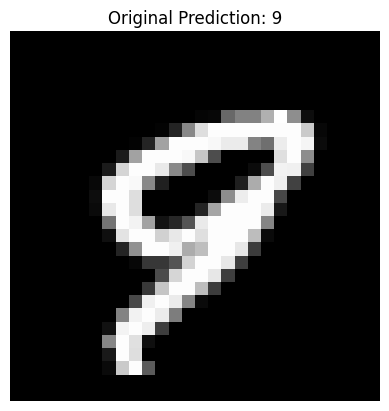

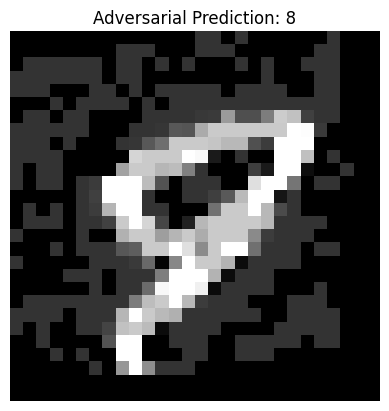

In [ ]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = fgsm_attack(
    model,
    loss_fn,
    images,
    labels,
    epsilon=0.2
)

# Original prediction
output1 = model(images)
pred1 = output1.argmax(dim=1)

# Adversarial prediction
output2 = model(adv_image)
pred2 = output2.argmax(dim=1)

show_image(images[0], f"Original Prediction: {pred1.item()}")

show_image(adv_image[0], f"Adversarial Prediction: {pred2.item()}")

**BIM(basic iterative method)**

In [ ]:
#BIM Attack Function
def bim_attack(model, loss_fn, image, label,
               epsilon=0.1,
               alpha=0.01,
               iterations=10):

    # Save original image
    original_image = image.clone().detach()

    # Create adversarial image
    perturbed_image = image.clone().detach()

    for i in range(iterations):

        perturbed_image.requires_grad = True

        # Forward pass
        output = model(perturbed_image)

        # Compute loss
        loss = loss_fn(output, label)

        # Clear gradients
        model.zero_grad()

        # Backpropagation
        loss.backward()

        # Get gradients
        gradient = perturbed_image.grad.data

        # Update image
        perturbed_image = perturbed_image + alpha * gradient.sign()

        # Limit perturbation
        eta = torch.clamp(
            perturbed_image - original_image,
            min=-epsilon,
            max=epsilon
        )

        # Apply perturbation constraint
        perturbed_image = original_image + eta

        # Keep pixels valid
        perturbed_image = torch.clamp(
            perturbed_image,
            0,
            1
        ).detach()

    return perturbed_image

In [ ]:
#BIM Accuracy Testing
def test_bim(model, loader,
             epsilon=0.1,
             alpha=0.01,
             iterations=10):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Generate BIM adversarial image
        adv_images = bim_attack(
            model,
            loss_fn,
            images,
            labels,
            epsilon,
            alpha,
            iterations
        )

        # Prediction
        outputs = model(adv_images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"BIM Accuracy: {accuracy:.2f}%")

In [ ]:
test_bim(
    model,
    test_loader,
    epsilon=0.1,
    alpha=0.01,
    iterations=10
)

BIM Accuracy: 83.74%


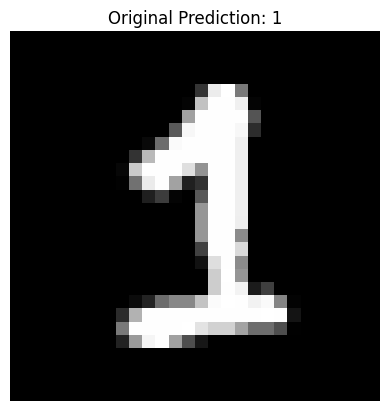

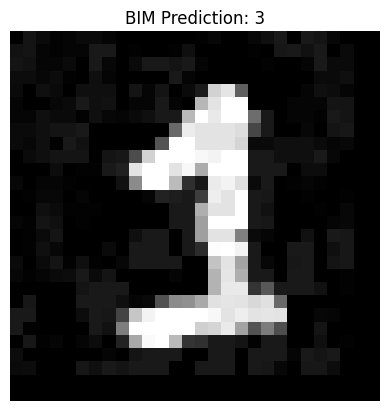

In [ ]:
# visualising orginal imgae vs BIM acctaked image
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = bim_attack(
    model,
    loss_fn,
    images,
    labels,
    epsilon=0.1,
    alpha=0.01,
    iterations=10
)

# Predictions
pred1 = model(images).argmax(dim=1)
pred2 = model(adv_image).argmax(dim=1)

show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"BIM Prediction: {pred2.item()}"
)

**PGD(Projected Gradient Decent)**

In [ ]:
#PGD ATTACK FUNCTION
def pgd_attack(model,
               loss_fn,
               image,
               label,
               epsilon=0.3,
               alpha=0.01,
               iterations=40):

    # Save original image
    original_image = image.clone().detach()

    # Random initialization (important difference)
    perturbed_image = original_image + torch.empty_like(
        original_image
    ).uniform_(-epsilon, epsilon)

    perturbed_image = torch.clamp(
        perturbed_image,
        0,
        1
    )

    for i in range(iterations):

        perturbed_image.requires_grad = True

        # Forward pass
        output = model(perturbed_image)

        # Compute loss
        loss = loss_fn(output, label)

        # Clear gradients
        model.zero_grad()

        # Backpropagation
        loss.backward()

        # Get gradients
        gradient = perturbed_image.grad.data

        # Gradient ascent step
        perturbed_image = perturbed_image + alpha * gradient.sign()

        # Projection step
        eta = torch.clamp(
            perturbed_image - original_image,
            min=-epsilon,
            max=epsilon
        )

        perturbed_image = original_image + eta

        # Keep valid pixel range
        perturbed_image = torch.clamp(
            perturbed_image,
            0,
            1
        ).detach()

    return perturbed_image

In [ ]:
#PGD Accuracy Testing
def test_pgd(model,
             loader,
             epsilon=0.3,
             alpha=0.01,
             iterations=40):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Generate PGD adversarial examples
        adv_images = pgd_attack(
            model,
            loss_fn,
            images,
            labels,
            epsilon,
            alpha,
            iterations
        )

        # Prediction
        outputs = model(adv_images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"PGD Accuracy: {accuracy:.2f}%")

In [ ]:
test_pgd(
    model,
    test_loader,
    epsilon=0.3,
    alpha=0.01,
    iterations=40
)

PGD Accuracy: 0.00%


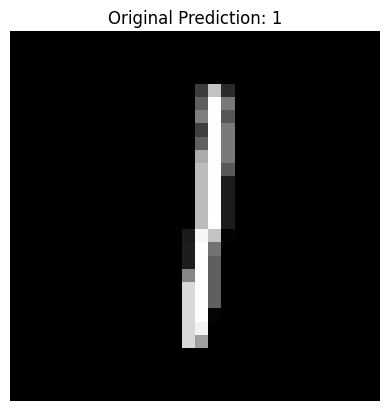

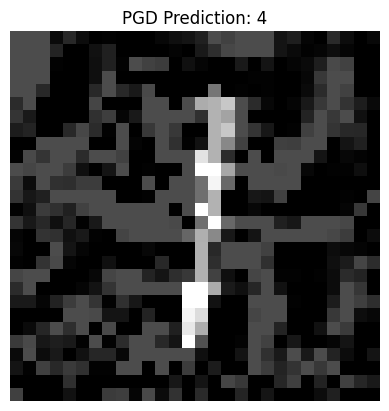

In [ ]:
#VISUALISING PGD attack
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = pgd_attack(
    model,
    loss_fn,
    images,
    labels,
    epsilon=0.3,
    alpha=0.01,
    iterations=40
)

# Predictions
pred1 = model(images).argmax(dim=1)
pred2 = model(adv_image).argmax(dim=1)

show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"PGD Prediction: {pred2.item()}"
)